In [1]:
suppressPackageStartupMessages({
    library(ggplot2)
    library(data.table)
    library(stringr)
    library(dplyr)
    library(parallel)
    library(glue)
    library(patchwork)
    library(ape)
    library(igraph)
    library(ggtree)
    library(tidygraph)
    library(ggrepel)
    library(ggtreeExtra)
    library(Seurat)
    library(Signac)
    library(numbat)
    library(mitodrift)
})
filter = dplyr::filter
options(repr.matrix.max.cols=15, repr.matrix.max.rows=50)
rename = dplyr::rename
R.utils::sourceDirectory('../../R')
R.utils::sourceDirectory('../../../tools/mitodrift/R')

Warning message:
“package ‘data.table’ was built under R version 4.4.3”
Warning message:
“package ‘SeuratObject’ was built under R version 4.4.3”
Warning message:
“package ‘Signac’ was built under R version 4.4.3”
Warning message:
“package ‘Matrix’ was built under R version 4.4.3”


# Define seurat clusters

In [2]:
donor = 'MM_BB094'
seu_clean = readRDS(glue('../../../mm_analysis/seurat/{donor}_tumor_clustered.rds'))

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


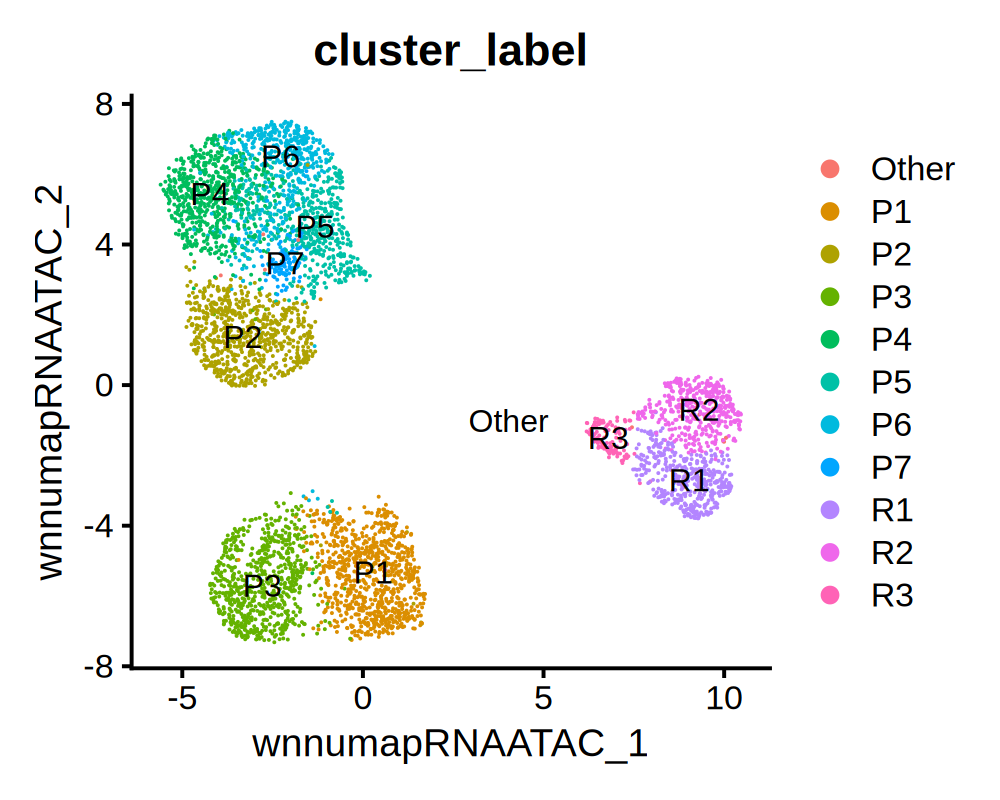

In [3]:
options(repr.plot.width = 5, repr.plot.height = 4, repr.plot.res = 200)

DimPlot(seu_clean, group.by = 'cluster_label', pt.size = 0.5, label = T, stroke = 0)

# MitoDrift phylogeny vs CNVs

In [4]:
sample = 'MM_BB094_plasma_all'
phy_annot = read.tree(glue('../../../mm_analysis/results/final/2025_jul21/{sample}/tree_annotated.newick'))
mut_dat = fread(glue('../../../mm_analysis/mut_dat/final/2025_jul21/{sample}_mut_dat.csv'))

In [5]:
p_conf = 0.075
phy_trim = phy_annot %>% trim_tree(conf = p_conf)
cells_tumor = seu_clean@meta.data %>% filter(compartment == 'tumor') %>% rownames(.)
phy_trim = phy_trim %>% keep_tip_safe(cells_tumor)
clade_annot = assign_clones_polytomy(phy_trim, k = Inf)

Registered S3 method overwritten by 'TreeTools':
  method   from    
  [.phyDat phangorn



In [6]:
rename_dict = c('1' = 'Normal', '2' = 'A', '3' = 'C1', '4' = 'C2', '5' = 'B')
seu_clean@meta.data = seu_clean@meta.data %>% 
    mutate(cnv_lineage = rename_dict[cnv_clone_knn]) %>%
    mutate(cell = rownames(.))

cnv_clone_mat = seu_clean@meta.data %>%
    mutate(I = cnv_lineage) %>%
    filter(cnv_lineage!='Normal') %>%
    reshape2::dcast(cnv_lineage ~ cell, fill = NA, value.var = 'cnv_lineage') %>%
    tibble::column_to_rownames('cnv_lineage') %>%
    as.matrix

storage.mode(cnv_clone_mat) <- "character"

# collapse C1 and C2
c = ifelse(!is.na(cnv_clone_mat["C1", ]), cnv_clone_mat["C1", ], cnv_clone_mat["C2", ])
c[c == "None"] = "None"

cnv_clone_mat2 = rbind(
	cnv_clone_mat[!rownames(cnv_clone_mat) %in% c("C1", "C2"), , drop = FALSE],
	C = c
)

Warning message:
“`aes_()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`
ℹ The deprecated feature was likely used in the ggtree package.
  Please report the issue at <https://github.com/YuLab-SMU/ggtree/issues>.”
Warning message in fortify(data, ...):
“Arguments in `...` must be used.
✖ Problematic arguments:
• as.Date = as.Date
• yscale_mapping = yscale_mapping
• branch.length = branch.length
• hang = hang
• linewidth = branch_width
ℹ Did you misspell an argument name?”
Found more than one class "phylo" in cache; using the first, from namespace 'tidytree'

Also defined by ‘TreeTools’

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Warning message:
“The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


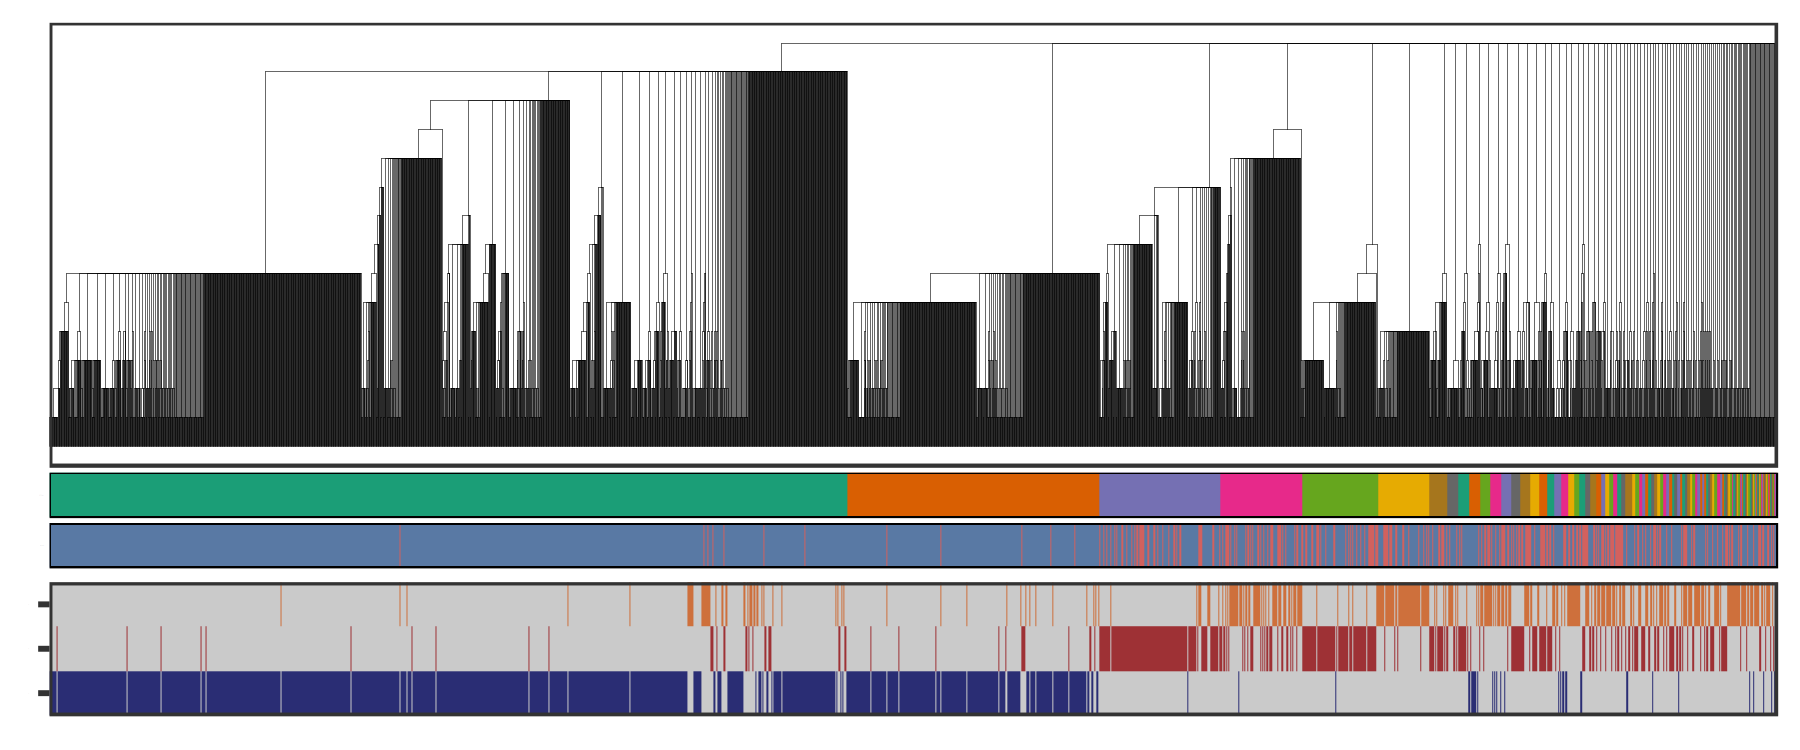

In [8]:
options(repr.plot.width = 6, repr.plot.height = 2.5, repr.plot.res = 300)
R.utils::sourceDirectory('../../../tools/mitodrift/R')

pal_timepoint = c('t1' = '#5979A4', 't2' = '#D2615E')

# Combine and create palette
n_clades = clade_annot %>% filter(size >= 2) %>% pull(clade) %>% unique %>% length
pal_clade = make_clade_pal(n_clades, pal = 'Dark2', cycle_len = 8, cycle_shift = 0)
clade_annot = clade_annot %>% mutate(color = pal_clade[clade]) %>%
    mutate(color = ifelse(size==1,'#CACACA',color))
pal_clade = clade_annot %>% {setNames(.$color,.$clade)}

pal_clone = c('A' = '#CE703C', 'C1' = '#2A2D74', 'C2' = '#2A2D74', 'B' = '#9E3135')

p = plot_phylo_heatmap2(
        phy_trim %>% drop_singletons(),
        # df_var = mut_dat,
        min_cells = 15,
        branch_length = F,
        branch_width = 0.05,
        het_max = 0.2,
        annot_legend = F,
        cell_annot = list(
            'MT Clade' = clade_annot,
            'Timepoint' = seu_clean@meta.data %>% mutate(cell = rownames(.), annot = timepoint)
        ),
        annot_pal = list(pal_clade, pal_timepoint),
        feature_mat = cnv_clone_mat2,
        rescale = F,
        feature_limits = c(0,1),
        feature_height = 0.3,
        feature_legend = F,
        feature_scale = scale_fill_manual(values = pal_clone, na.value = '#CACACA'),
        show_variant_names = FALSE,
        text_size = 0,
        raster = TRUE,
        raster_dpi = 300
    ) & theme_transparent %>%
    suppressWarnings() %>%
    suppressWarnings()

p 

ggsave(glue('outputs/MM_BB094_tumor_full_tree.pdf'), p, width = 6, height = 2.5)

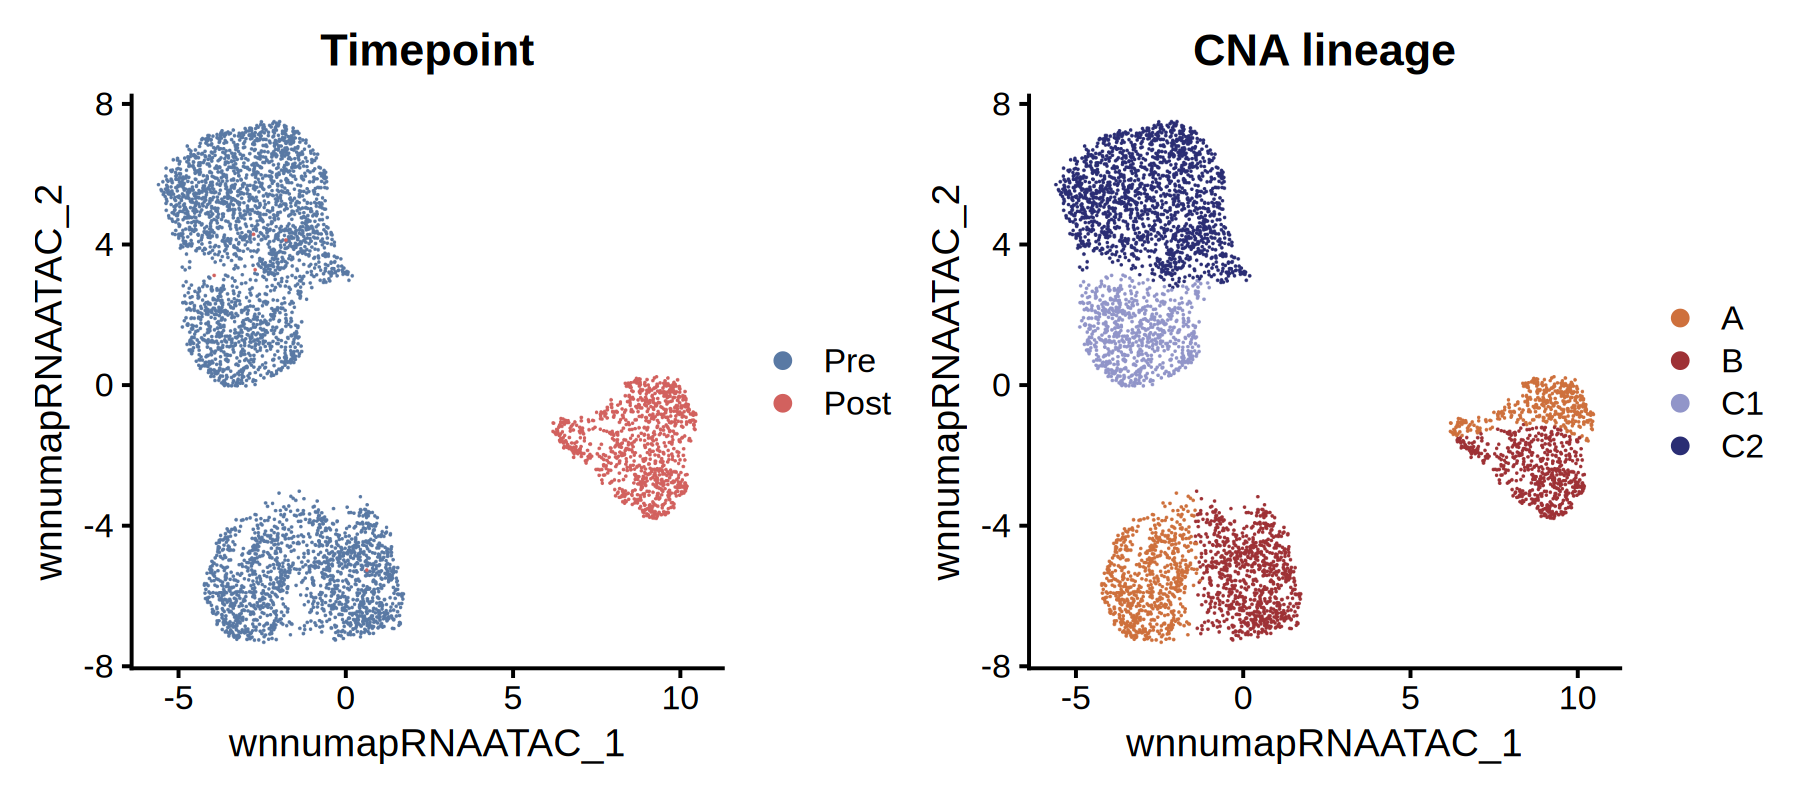

In [61]:
options(repr.plot.width = 9, repr.plot.height = 4, repr.plot.res = 200)

p1 = DimPlot(
        seu_clean, group.by = 'timepoint', pt.size = 0.5,
        label = F, stroke = 0
    ) + 
    ggtitle('Timepoint') +
    scale_color_manual(values = pal_timepoint, labels = c('t1' = 'Pre', 't2' = 'Post'))

pal_clone2 = c('A' = '#CE703C', 'C1' = '#9195C9', 'C2' = '#2A2D74', 'B' = '#9E3135')

p2 = DimPlot(
        seu_clean, group.by = 'cnv_lineage', cols = pal_clone2, pt.size = 0.5, 
        label = F, stroke = 0
    ) +
    ggtitle('CNA lineage')

p1 = p1 %>% ggrastr::rasterize(layers = 'Point', dpi = 300)
p2 = p2 %>% ggrastr::rasterize(layers = 'Point', dpi = 300)

panel = (p1 | p2) & theme_transparent

panel

ggsave(glue('outputs/MM_BB094_cnv_umap.pdf'), panel, width = 9, height = 4)

In [15]:
cnv_lineage_dict = seu_clean@meta.data %>% {setNames(.$cnv_lineage, .$cell)}
cnv_lineage_dict[cnv_lineage_dict == 'C1'] = 'C'
cnv_lineage_dict[cnv_lineage_dict == 'C2'] = 'C'
test_dat = run_path(drop_singletons(phy_trim), cnv_lineage_dict, diag_only = T)

In [16]:
test_dat

state,z,cor,lower,upper,p,q
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A,90.49108,0.4129596,0.4040101,0.4219092,0,0
B,118.00155,0.5386358,0.5296853,0.5475863,0,0
C,166.97960,0.7624361,0.7534840,0.7713882,0,0


# Combined 1q lineage

In [15]:
cell_annot = seu_clean@meta.data %>% 
    mutate(cell = rownames(.)) %>%
    select(cell, cnv_clone = cnv_clone_knn, timepoint) %>%
    inner_join(
        clade_annot %>% filter(size > 1) %>% 
            mutate(clade = factor(clade, levels = sort(as.integer(unique(clade))))) %>%
            select(cell, mt_clone = clade), 
        by = join_by(cell)
    )

In [16]:
cells_1q = seu_clean@meta.data %>% 
    filter(cnv_clone_knn == '5') %>%
    filter(rownames(.) %in% phy_trim$tip.label) %>%
    rownames(.)

phy_trim_select = phy_trim %>% keep_tip_safe(cells_1q)
clade_annot_select = assign_clones_polytomy(phy_trim_select, k = Inf)

In [17]:
phy_test = phy_trim_select %>% drop_singletons() %>% add_node_names()
timepoint_dict = seu_clean@meta.data %>% {setNames(.$timepoint, rownames(.))}
score_dict = as.integer(timepoint_dict == 't2') %>% setNames(names(timepoint_dict))
# names(score_dict) = sample(names(score_dict))
node_scores = compute_internal_node_scores(phy_test, score_dict, singletons = T, min_clade_size = 5)
score_dict = node_scores %>% {setNames(.$z_adj, .$label)}
score_dict_prop = propagate_scores_down_max(phy_test, score_dict, threshold = 0)
node_scores = node_scores %>% mutate(z_adj_prop = score_dict_prop[label])

In [10]:
node_scores %>% pull(z_adj) %>% summary

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
-3.7732 -0.3963 -0.0869 -0.2497  0.2421  1.9130     607 

In [19]:
node_scores %>% pull(z_adj) %>% summary

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
-3.7732 -0.3963 -0.0869 -0.2497  0.2421  1.9130     607 

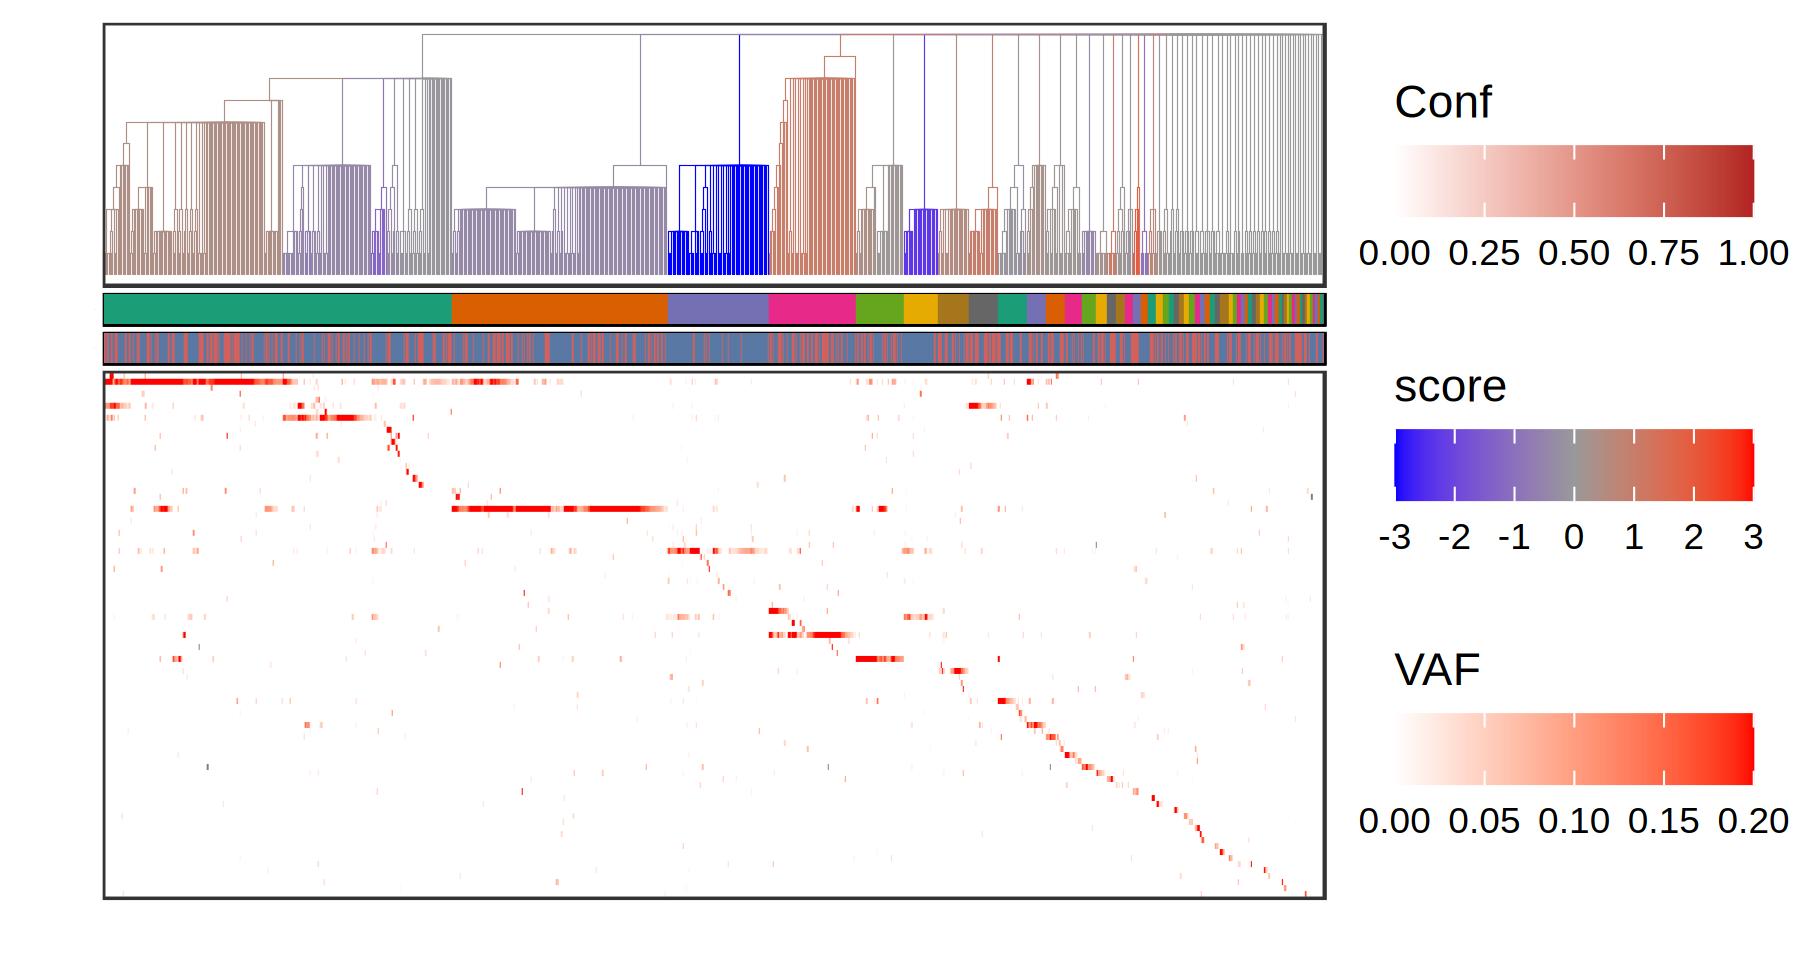

In [18]:
options(repr.plot.width = 6, repr.plot.height = 3.25, repr.plot.res = 300)
R.utils::sourceDirectory('../../../tools/mitodrift/R')

pal_timepoint = c('t1' = '#5979A4', 't2' = '#D2615E')
n_clades = clade_annot_select %>% filter(size >= 2) %>% pull(clade) %>% unique %>% length
pal_clade = make_clade_pal(n_clades, pal = 'Dark2', cycle_len = 8, cycle_shift = 0)

# Generate plot with legends
p = plot_phylo_heatmap2(
    phy_test,
    mut_dat,
    node_conf = T,
    branch_length = F,
    branch_width = 0.1,
    het_max = 0.2,
    annot_legend = F, 
    show_variant_names = F,
    cell_annot = list(
        'Clade' = clade_annot_select %>% filter(size >= 2),
        'Timepoint' = seu_clean@meta.data %>% mutate(cell = rownames(.), annot = timepoint)
    ),
    annot_pal = list(pal_clade, pal_timepoint),
    node_scores = node_scores %>% {setNames(.$z_adj_prop, .$node)},
    ytitle = '',
    xtitle = '',
    min_cells = 4,
    annot_bar_height = 0.125,
    text_size = 0,
    node_score_limits = c(-3,3),
    raster = T,
    raster_dpi = 300
) %>%
suppressWarnings() %>%
suppressMessages() &
theme_transparent &
theme(legend.title.position = 'top',
      legend.direction = 'horizontal')

p

# Extract legends
leg = cowplot::get_legend(p)
p_legend = cowplot::ggdraw(leg)

# Save main plot without legends
ggsave(
    glue('outputs/MM_BB094_1q_all_tree.pdf'),
    p & theme(legend.position = "none"),
    width = 5, height = 3.25
)

# Save legends separately
ggsave(glue('outputs/MM_BB094_1q_all_tree_legend.pdf'), p_legend, width = 2, height = 2)

In [24]:
tp_dict = seu_clean@meta.data %>% {setNames(.$timepoint_label, rownames(.))}
run_path(phy_test, tp_dict)

state_x,state_y,z,cor,lower,upper,p,q
<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Post,Post,4.318192,0.06272378,0.03377761,0.09166996,1.573125e-05,1.573125e-05
Pre,Post,-4.318192,-0.06272378,-0.09166996,-0.03377761,1.573125e-05,1.573125e-05
Post,Pre,-4.318192,-0.06272378,-0.09166996,-0.03377761,1.573125e-05,1.573125e-05
Pre,Pre,4.318192,0.06272378,0.03377761,0.09166996,1.573125e-05,1.573125e-05


# Subclonal lineage

In [6]:
# select 1q subclone in primary
cells_select = seu_clean@meta.data %>% 
    filter(cnv_clone_knn == '5' & timepoint == 't1') %>%
    filter(rownames(.) %in% phy_trim$tip.label) %>%
    rownames(.)

cells_1q = seu_clean@meta.data %>% 
    filter(cnv_clone_knn == '5') %>%
    filter(rownames(.) %in% phy_trim$tip.label) %>%
    rownames(.)

phy_trim_select = phy_trim %>% keep_tip_safe(cells_select)

# subset seurat and recluster
seu_subclone = subset(seu_clean, cells = cells_select)
set.seed(0)
seu_subclone = compute_new_wnn(seu_subclone, cluster_res = 0.75) %>% suppressWarnings()

In [7]:
cluster_res = 0.5

seu_subclone <- FindClusters(
    seu_subclone, graph.name = "wsnn", algorithm = 1, 
    resolution = cluster_res, verbose = FALSE,
    cluster.name = 'reclust'
)

rename_dict = c('1' = 'P1A', '2' = 'P1B', '3' = 'P1C', '4' = 'P1D')

sub_cluster_dict = seu_subclone@meta.data %>% {setNames(rename_dict[.$reclust], rownames(.))}
seu_subclone@meta.data = seu_subclone@meta.data %>% mutate(reclust_label = rename_dict[reclust])

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


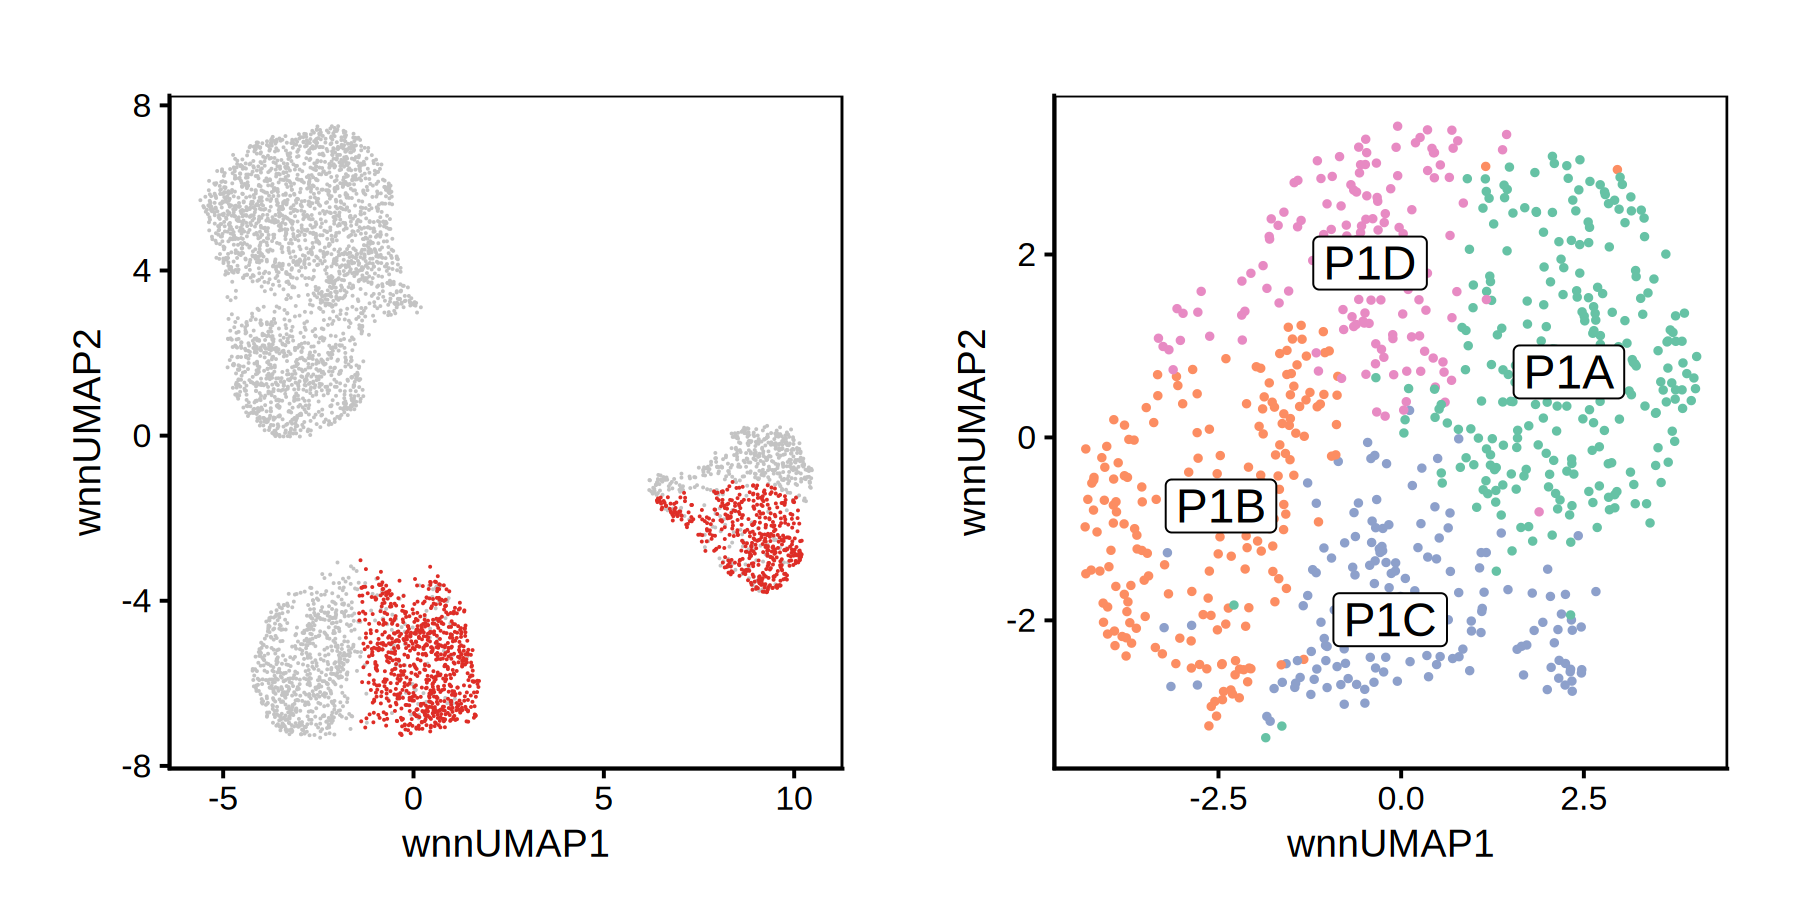

In [8]:
options(repr.plot.width = 9, repr.plot.height = 4.5, repr.plot.res = 200)

pal_reclust = RColorBrewer::brewer.pal(n = 4, name = 'Set2') %>% setNames(unname(rename_dict))

p1 = DimPlot(seu_clean, pt.size = 0.5, cells.highlight = cells_1q, sizes.highlight = 0.5, stroke.size = 0) + 
    ggtitle('') +
    theme(legend.position = 'none') +
    theme(aspect.ratio = 1) +
    theme_transparent +
    xlab('wnnUMAP1') +
    ylab('wnnUMAP2') +
    theme(panel.border = element_rect(fill = NA, size = 0.5, color = 'black'))

p2 = DimPlot(seu_subclone, group.by = 'reclust_label', pt.size = 0.5, cells = cells_select, cols = pal_reclust) %>%
    LabelClusters(id = 'reclust_label', box = T, fill = 'white', segment.size = 0, segment.color = NA, size = 6, force = 0) +
    ggtitle('') +
    theme(legend.position = 'none') +
    theme(aspect.ratio = 1) +
    theme_transparent + 
    xlab('wnnUMAP1') +
    ylab('wnnUMAP2') +
    theme(panel.border = element_rect(fill = NA, size = 0.5, color = 'black'))

p1 | p2

ggsave('outputs/1q_highlight_umap.pdf', p1, width = 4, height = 4)
ggsave('outputs/1q_reclust_umap.pdf', p2, width = 4, height = 4)

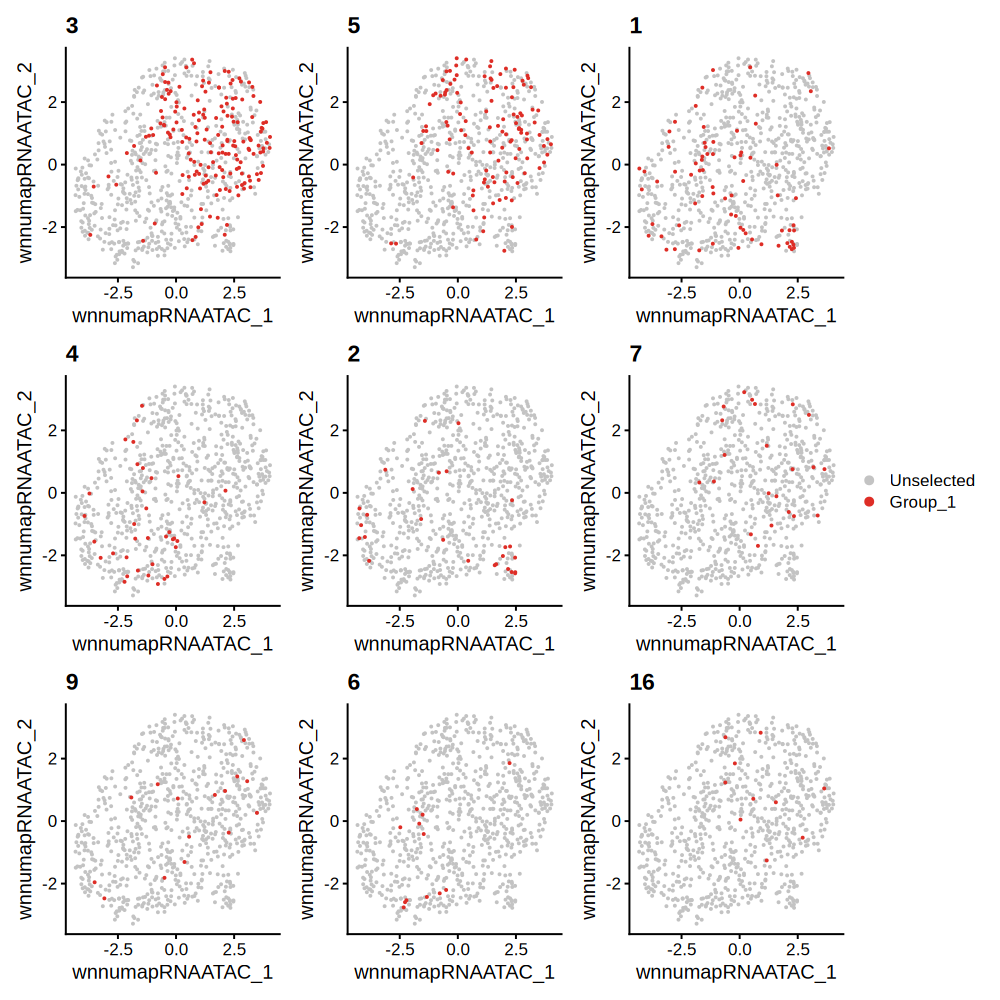

In [25]:
options(repr.plot.width = 10, repr.plot.height = 10, repr.plot.res = 100)

clade_annot_subclone = clade_annot %>% 
    filter(cell %in% cells_select) %>%
    group_by(clade) %>%
    mutate(size = n()) %>%
    ungroup() %>%
    filter(size >= 10) %>%
    arrange(-size) %>%
    mutate(clade = factor(clade, unique(clade)))

clade_annot_subclone %>% 
split(.$clade) %>%
lapply(
    function(annot) {
        DimPlot(seu_subclone, cells.highlight = annot$cell, pt.size = 1, sizes.highlight = 1, stroke.size = 0, order = T) +
        ggtitle(unique(annot$clade))
    }
) %>%
wrap_plots(guides = 'collect')

Warning message in fortify(data, ...):
“Arguments in `...` must be used.
✖ Problematic arguments:
• as.Date = as.Date
• yscale_mapping = yscale_mapping
• branch.length = branch.length
• hang = hang
• linewidth = branch_width
ℹ Did you misspell an argument name?”
Found more than one class "phylo" in cache; using the first, from namespace 'tidytree'

Also defined by ‘TreeTools’

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


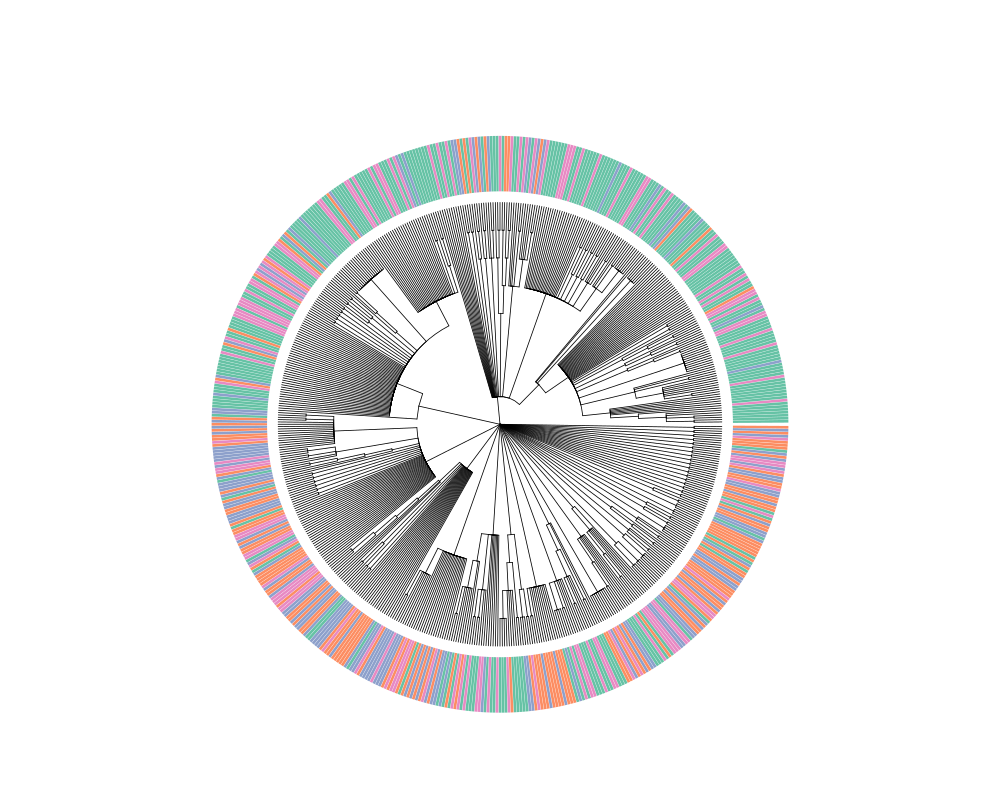

In [29]:
options(repr.plot.width = 5, repr.plot.height = 4, repr.plot.res = 200)

p = plot_phylo_circ(
    phy_trim_select %>% drop_singletons(),
    branch_width = 0.1,
    annot_legend = F,
    cell_annot = list(
        'subcluster' = seu_subclone@meta.data %>% mutate(cell, annot = rename_dict[reclust])
    ),
    annot_pal = pal_reclust
) & theme_transparent

p

ggsave('outputs/1q_tree_state.pdf', p, width = 4, height = 4)

In [64]:
phy_trim_select %>% drop_singletons()


Phylogenetic tree with 595 tips and 179 internal nodes.

Tip labels:
  MM_BB094_t1_TGTAAAGCAACCGCCA-1, MM_BB094_t1_GTTACAGGTGTTGTAG-1, MM_BB094_t1_GTGCGGTTCGAGGAGT-1, MM_BB094_t1_GCCTTGCGTAATAGCT-1, MM_BB094_t1_ATTTAGCCACAATGCC-1, MM_BB094_t1_CAAACTGGTAGGATCC-1, ...
Node labels:
  1, 0.841591584084159, 0.108386416135839, 0.101747482525175, 0.0863236367636324, 0.611732382676173, ...

Unrooted; no branch length.

## Find markers

In [30]:
markers_rna = FindAllMarkers(seu_subclone, assay = 'RNA', group.by = 'reclust_label', only.pos = T, test.use = 'wilcox')

Calculating cluster P1A

Found more than one class "phylo" in cache; using the first, from namespace 'tidytree'

Also defined by ‘TreeTools’

Warning message:
“`PackageCheck()` was deprecated in SeuratObject 5.0.0.
ℹ Please use `rlang::check_installed()` instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Calculating cluster P1C

Found more than one class "phylo" in cache; using the first, from namespace 'tidytree'

Also defined by ‘TreeTools’

Calculating cluster P1D

Found more than one class "phylo" in cache; using the first, from namespace 'tidytree'

Also defined by ‘TreeTools’

Calculating cluster P1B

Found more than one class "phylo" in cache; using the first, from namespace 'tidytree'

Also defined by ‘TreeTools’



In [31]:
state_order = unname(rename_dict)

In [33]:
marker_dat_rna = get_marker_dat(markers_rna, state_order, sub_cluster_dict, GetAssayData(seu_subclone[['RNA']]))

In [34]:
marker_dat_rna$top_markers %>% fwrite('outputs/mm_subclone_rna_markers.csv')

In [23]:
# pal: named vector of colors, names(pal) are the original cluster ids (e.g. "P1A","P1B"...)
# labels_short: optional named vector mapping cluster id -> short label (same names as pal)
make_legend_ggplot <- function(pal, labels_short = NULL, title = NULL, ncol = 1) {
	stopifnot(is.character(pal), !is.null(names(pal)))

	ids <- names(pal)

	if (is.null(labels_short)) {
		lbls <- ids
	} else {
		stopifnot(is.character(labels_short), !is.null(names(labels_short)))
		lbls <- unname(labels_short[ids])
		if (anyNA(lbls)) {
			missing_ids <- ids[is.na(lbls)]
			stop("labels_short is missing entries for: ", paste(missing_ids, collapse = ", "))
		}
	}

	df <- data.frame(
		id = factor(ids, levels = ids),
		label = factor(lbls, levels = lbls),
		x = seq_along(ids),
		y = 1
	)

	p_dummy <- ggplot(df, aes(x = x, y = y, color = id)) +
		geom_point(size = 4) +
		scale_color_manual(values = pal, breaks = ids, labels = lbls, drop = FALSE) +
		guides(color = guide_legend(title = title, ncol = ncol, override.aes = list(size = 4))) +
		theme_void() +
		theme(legend.position = "right")

	leg <- cowplot::get_legend(p_dummy)
	p_legend <- cowplot::ggdraw(leg)

	return(p_legend)
}

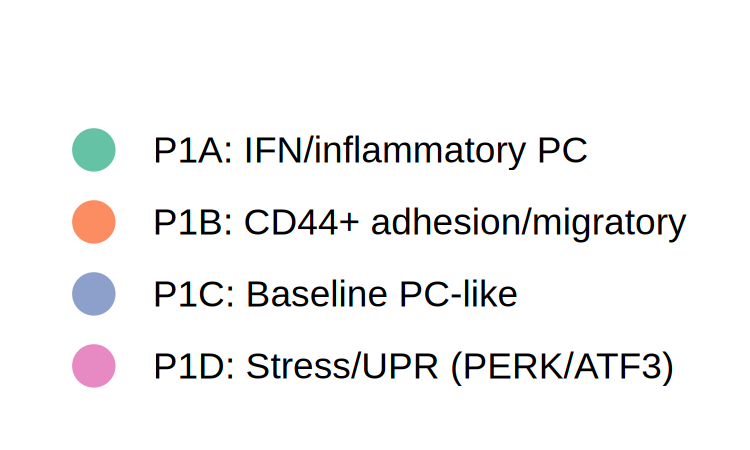

In [45]:
options(repr.plot.width = 2.5, repr.plot.height = 1.5, repr.plot.res = 300)

cluster_labels_short <- c(
	`P1A` = "IFN/inflammatory PC",
	`P1B` = "CD44+ adhesion/migratory",
	`P1C` = "Baseline PC-like",
	`P1D` = "Stress/UPR (PERK/ATF3)"
)

cluster_labels = cluster_labels_short %>% {setNames(paste0(names(.), ': ', unname(.)), names(.))}

p_leg = make_legend_ggplot(
    pal_reclust,
    title = "",
    ncol = 1, 
    labels_short = cluster_labels
) +
theme_transparent +
theme(plot.margin = margin(0,0,0,0))

p_leg

ggsave('outputs/1q_state_legend.pdf', p_leg, width = 2.5, height = 1.5)

## Cell state transitions

In [21]:
rename_dict = c('1' = 'P1A', '2' = 'P1B', '3' = 'P1C', '4' = 'P1D')
cluster_dict = seu_subclone@meta.data %>% {setNames(rename_dict[.$reclust], rownames(.))}

path_res_mt = phy_trim_select %>% 
    drop_singletons() %>%
    run_path(cluster_dict, min_count = 10)

tmat = run_path_inf(phy_trim, cluster_dict, min_count = 50)$Pt
state_order = c("P1C", "P1B", "P1A", "P1D")

In [179]:
# options(repr.plot.width = 4, repr.plot.height = 3.25, repr.plot.res = 200)

# p1 = plot_coupling_triangle(path_res_mt, state_order, mark_signif = T, statistic = 'cor', limits = c(-1,1))
# p2 <- plot_coupling_ribbons(
#         tmat,
#         state_order = state_order,
#         node_fill_map = node_fill_dict,
#         node_size_map = node_size_dict
#     ) +
#     scale_y_continuous(limits = c(0, 0), expand = expansion(mult = c(0, 0))) +
#     theme(
#         axis.text = element_blank(),
#         axis.title = element_blank(),
#         plot.margin = margin(t = 0, r = 10, b = 30, l = 10)
#     )

Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.


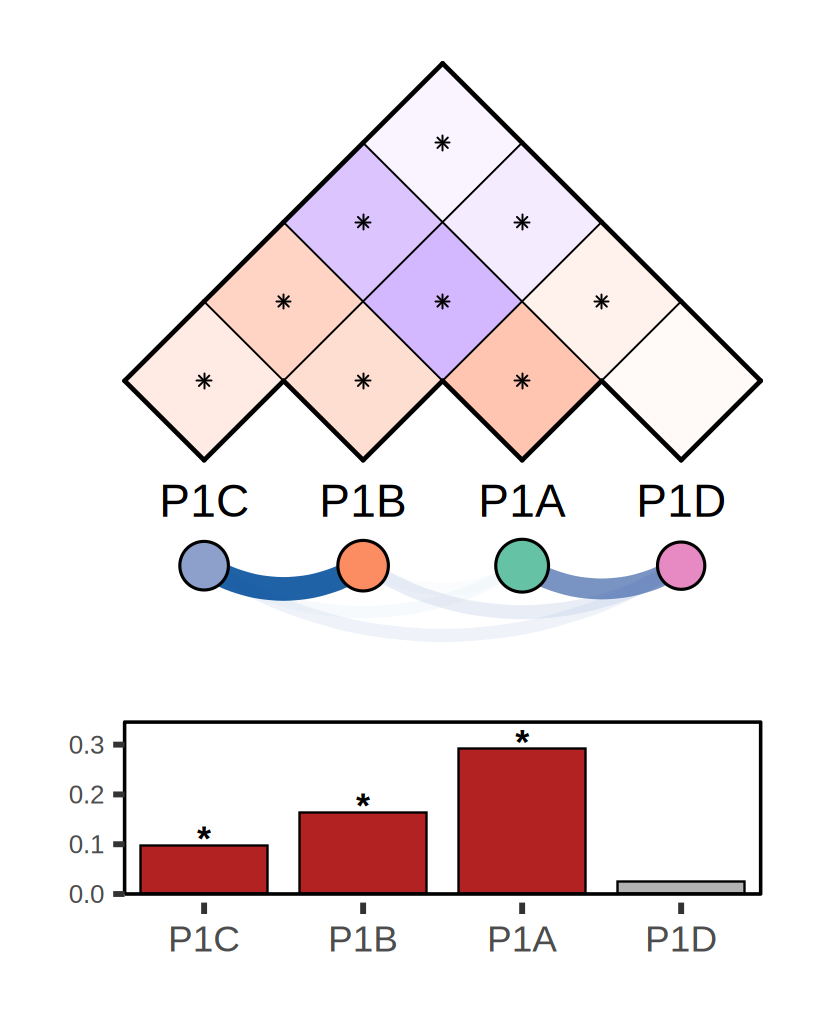

In [24]:
options(repr.plot.width = 2.75, repr.plot.height = 3.4, repr.plot.res = 300)
R.utils::sourceDirectory('../../R')

node_fill_dict = pal_reclust
node_size_dict = log(c(table(cluster_dict)))

p = plot_coupling_panel(
    path_res_mt, tmat, 
    state_order = state_order,
    linewidth_range = c(1,2),
    node_fill_map = node_fill_dict, 
    node_size_map = node_size_dict,
    limits = c(-50,50), 
    # self_coupling_limits = c(0,0.35),
    statistic = 'z',
    mark_signif = T,
    self_coupling_height = 1.3
)

leg = cowplot::get_legend(p)
p_leg = cowplot::ggdraw(leg)
p = p & theme(legend.position = 'none', legend) & theme_transparent

p

ggsave('outputs/1q_state_coupling.pdf', p, width = 2.75, height = 3.4)

In [26]:
path_res_mt %>% filter(state_x == state_y)

state_x,state_y,z,cor,lower,upper,p,q
<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
P1A,P1A,15.188573,0.29192086,0.25403356,0.32980815,4.209851e-52,5.633981e-51
P1B,P1B,8.609190,0.16446046,0.12663621,0.20228471,7.357832e-18,1.471566e-17
P1C,P1C,5.149952,0.09768952,0.05987023,0.13550881,2.605526e-07,4.632047e-07
P1D,P1D,1.370373,0.02475818,-0.01305982,0.06257617,1.705706e-01,1.705706e-01


## Distance to relapse

In [37]:
rename_dict = c('1' = 'P1A', '2' = 'P1B', '3' = 'P1C', '4' = 'P1D')
reclust_dict = seu_subclone@meta.data %>% {setNames(rename_dict[.$reclust], rownames(.))}

cluster_dict = seu_clean@meta.data %>% 
    mutate(group = ifelse(timepoint == 't2', 'Relapse', as.character(reclust_dict[rownames(.)]))) %>%
    {setNames(.$group, rownames(.))}

cluster_dict = cluster_dict[!is.na(cluster_dict)]

phy_test = phy_trim %>% drop_singletons()

res_dist = compute_comdist(phy_test, cluster_dict, B = 100, ncores = 8)

[1] 4185 4185


Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by ‘BiocGenerics’

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by ‘BiocGenerics’



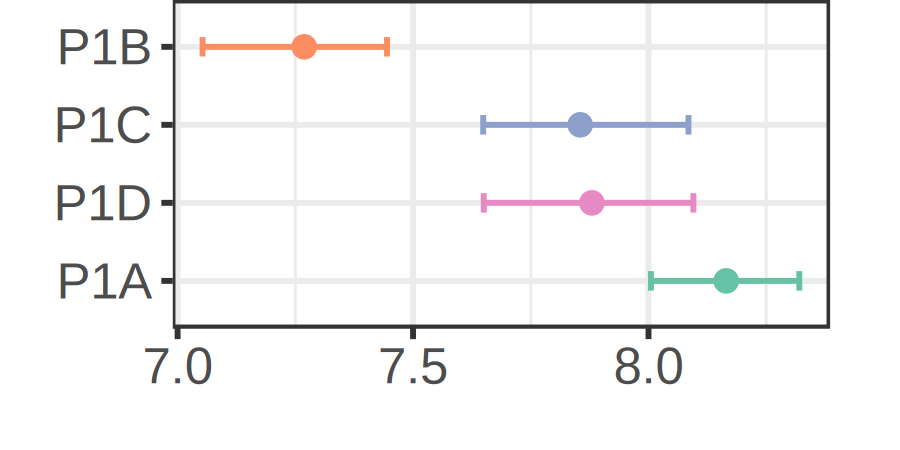

In [38]:
options(repr.plot.width = 3, repr.plot.height = 1.5, repr.plot.res = 300)

p = res_dist %>%
    filter(com_x == 'Relapse' & com_y != 'Relapse') %>%
    arrange(-obs) %>%
    mutate(com_y = factor(com_y, com_y)) %>%
    ggplot(
        aes(x = com_y, y = obs, ymin = lower, ymax = upper, color = com_y)
    ) + 
    geom_errorbar(width = 0.25) +
    geom_point(size = 2) +
    theme_bw() +
    xlab('') +
    ylab('') +
    theme(axis.text = element_text(size = 12)) +
    coord_flip() +
    theme(plot.margin = margin(r = 6, b = 0, l = 0, t = 0, unit = 'mm')) +
    scale_color_manual(values = pal_reclust) +
    theme(legend.position = 'none') +
    theme_transparent

p

ggsave('outputs/1q_com_dist_bar.pdf', p, width = 3, height = 1.5)

In [39]:
seu_subclone <- FindClusters(
    seu_subclone, graph.name = "wsnn", algorithm = 1, 
    resolution = 3, verbose = FALSE,
    cluster.name = 'reclust_fine'
)

reclust_dict = seu_subclone@meta.data %>% {setNames(.$reclust_fine, rownames(.))}

cluster_dict = seu_clean@meta.data %>% 
    mutate(group = ifelse(timepoint == 't2', 'Relapse', reclust_dict[rownames(.)])) %>%
    {setNames(.$group, rownames(.))}

cluster_dict = cluster_dict[!is.na(cluster_dict)]

phy_test = phy_trim %>% drop_singletons()

res_dist = compute_comdist(phy_test, cluster_dict, B = 0, ncores = 8)

[1] 4185 4185


Warning message:
“The `slot` argument of `FetchData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


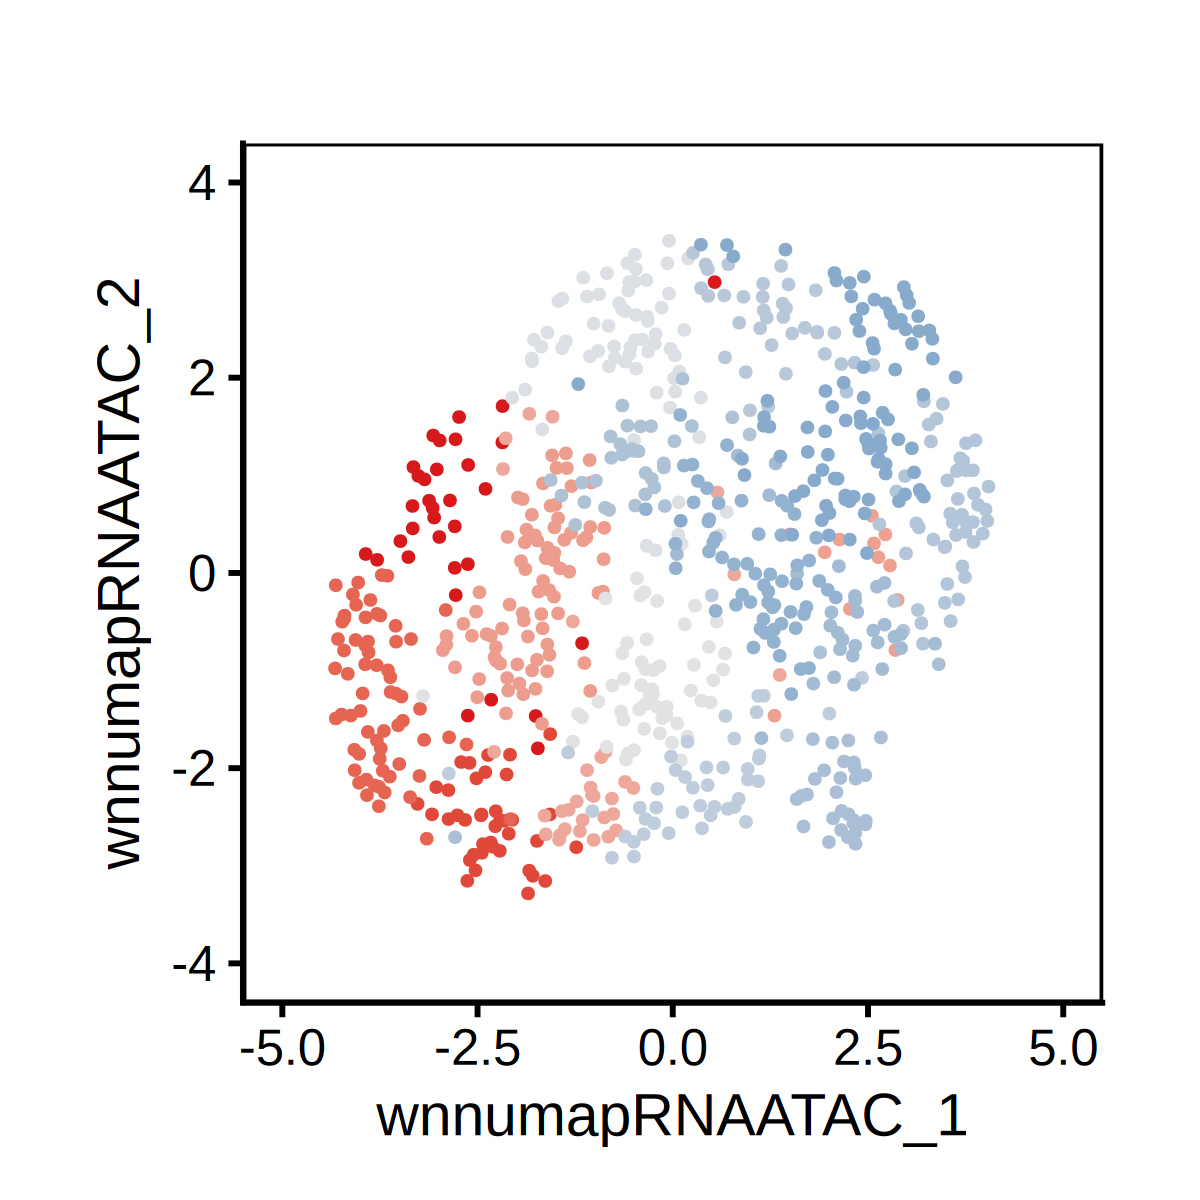

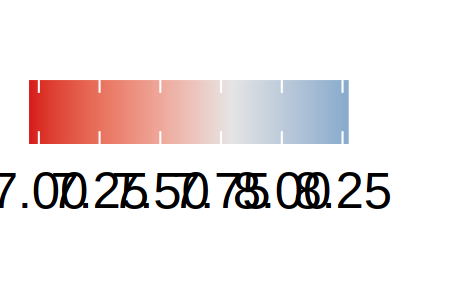

In [40]:
cluster_dist_dict = res_dist %>%
    filter(com_x == 'Relapse' & com_y != 'Relapse') %>%
    {setNames(.$obs, .$com_y)}

seu_subclone = AddMetaData(
    seu_subclone,
    data.frame(r_dist = cluster_dist_dict[unname(cluster_dict)] %>% setNames(names(cluster_dict)))
)

p = FeaturePlot(
        seu_subclone, features = 'r_dist', pt.size = 0.5, order = T
    ) +
    scale_color_gradient2(high = "#2B83BA", mid = "grey90", low = "#D7191C", midpoint = mean(cluster_dist_dict), name = '') +
    theme(legend.position = 'none') +
    ggtitle('') +
    theme(aspect.ratio = 1) +
    theme(panel.border = element_rect(fill = NA, size = 0.5, color = 'black')) +
    theme_transparent

leg = cowplot::get_legend(p + theme(legend.position = 'top'))

options(repr.plot.width = 4, repr.plot.height = 4, repr.plot.res = 300)
p

options(repr.plot.width = 1.5, repr.plot.height = 1, repr.plot.res = 300)
ggpubr::as_ggplot(leg)

ggsave('outputs/1q_com_dist.pdf', p, width = 4, height = 4)

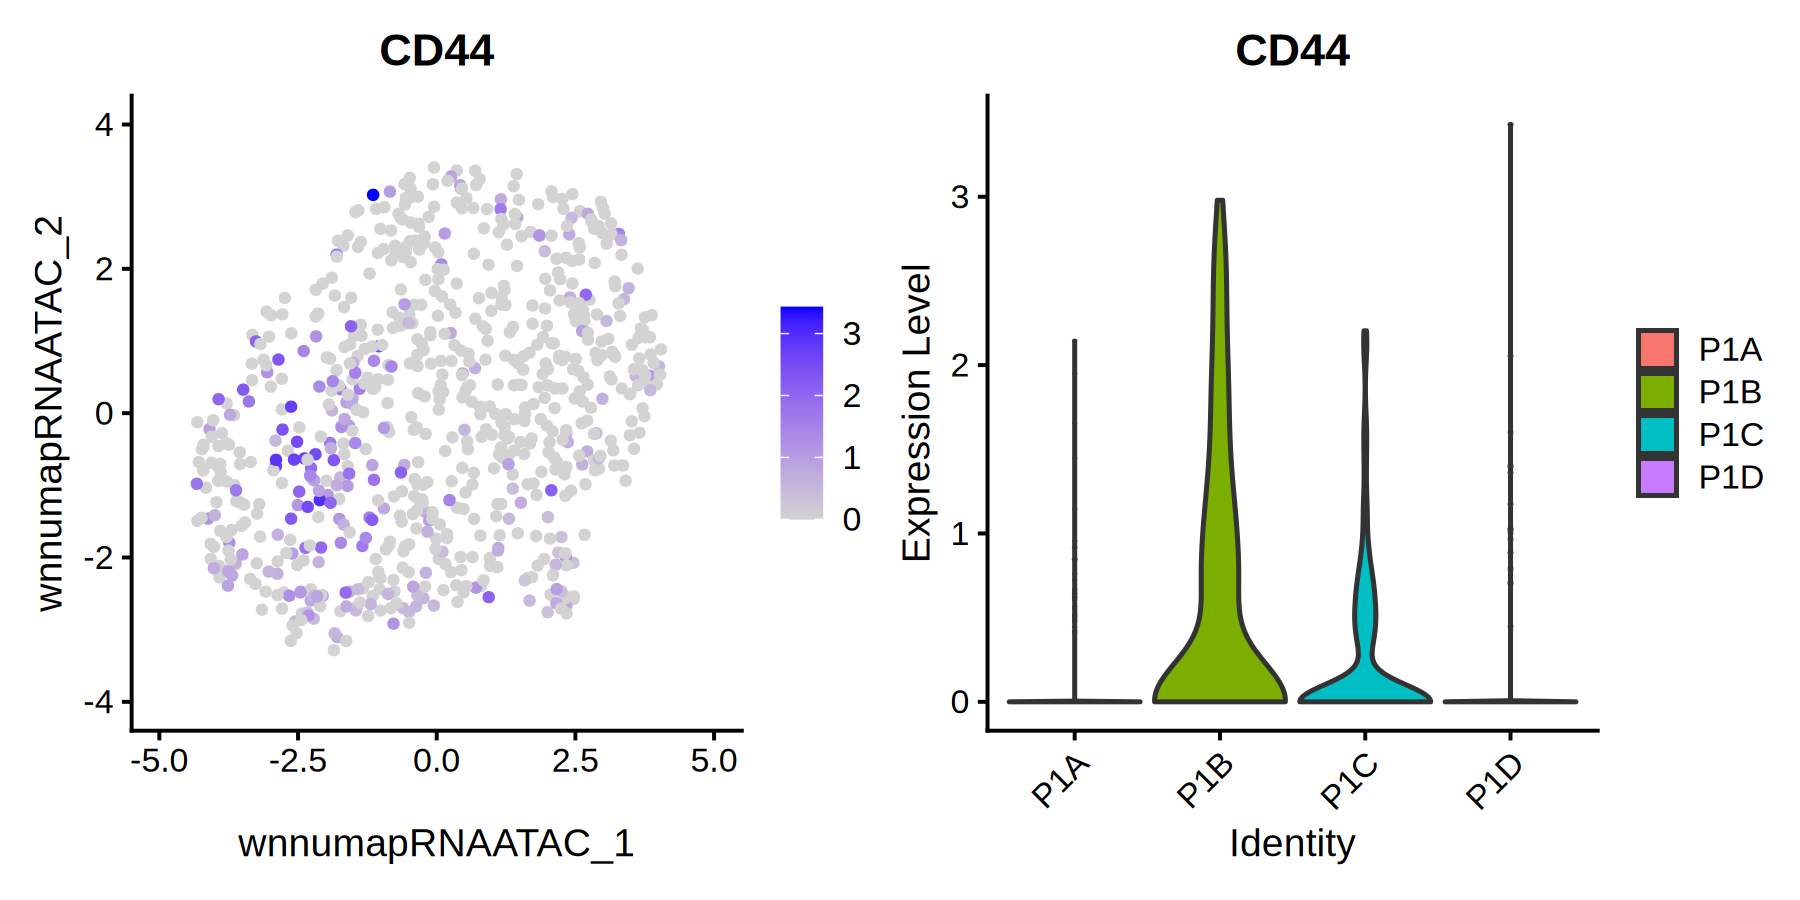

In [15]:
options(repr.plot.width = 9, repr.plot.height = 4.5, repr.plot.res = 200)

DefaultAssay(seu_subclone) = 'RNA'
p1 = FeaturePlot(seu_subclone, feature = 'CD44')
p2 = VlnPlot(
	seu_subclone,
	features = "CD44",
	group.by = "reclust_label",
	assay = "RNA",
	pt.size = 0
)

p1 | p2

# Clone-based analysis of CD44

In [21]:
clade_annot = clade_annot %>% 
    select(-any_of(c('timepoint_label'))) %>%
    left_join(
        seu_clean@meta.data %>% select(timepoint_label, cell),
        by = join_by(cell)
    )

In [34]:
clade_table = clade_annot %>% filter(size > 5) %>%
    group_by(clade) %>%
    summarise(
        n_pre = sum(timepoint_label == 'Pre'), 
        n_post = sum(timepoint_label == 'Post'), 
        frac_post = n_post/(n_pre+n_post)
    ) %>%
    arrange(-frac_post) %>%
    mutate(clade = factor(clade, unique(clade)))

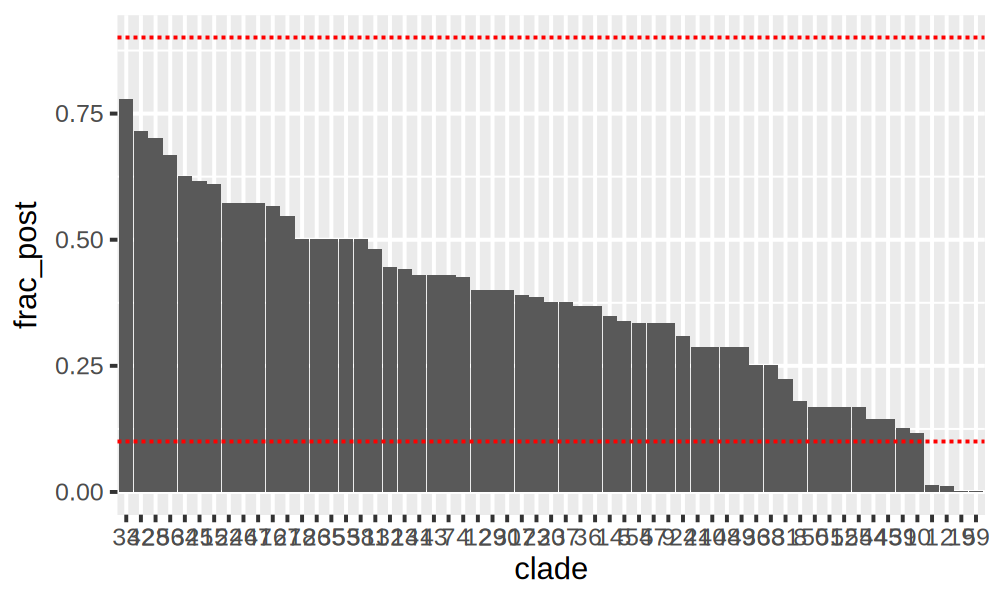

In [39]:
options(repr.plot.width = 5, repr.plot.height = 3, repr.plot.res = 200)

clade_table %>%
ggplot(
    aes(x = clade, y = frac_post)
) +
geom_col() +
geom_hline(yintercept = 0.1, color = 'red', linetype = 'dashed') +
geom_hline(yintercept = 0.9, color = 'red', linetype = 'dashed')

In [40]:
clones_include = clade_table %>% filter(frac_post > 0.1) %>% pull(clade)

In [41]:
# Per-clone mean CD44 by timepoint; keep clones with both Pre and Post
cd44_expr = GetAssayData(seu_clean[['RNA']])['CD44', ]

cd44_dat = clade_annot %>%
    filter(clade %in% clones_include) %>%
    mutate(CD44 = cd44_expr[cell])

cd44_clone = cd44_dat %>%
    group_by(clade, timepoint_label) %>%
    summarise(mean_CD44 = mean(CD44, na.rm = TRUE), .groups = 'drop') %>%
    group_by(clade) %>%
    filter(all(c('Pre', 'Post') %in% timepoint_label)) %>%
    ungroup()

# Paired Wilcoxon test: Post vs Pre, paired by clone
pre_vals  = cd44_clone %>% filter(timepoint_label == 'Pre')  %>% arrange(clade) %>% pull(mean_CD44)
post_vals = cd44_clone %>% filter(timepoint_label == 'Post') %>% arrange(clade) %>% pull(mean_CD44)

wilcox_res = wilcox.test(post_vals, pre_vals, paired = TRUE, alternative = 'two.sided')
message(glue('n clones = {length(pre_vals)}, p = {signif(wilcox_res$p.value, 3)}'))
wilcox_res

n clones = 55, p = 3.98e-06




	Wilcoxon signed rank test with continuity correction

data:  post_vals and pre_vals
V = 1321, p-value = 3.981e-06
alternative hypothesis: true location shift is not equal to 0


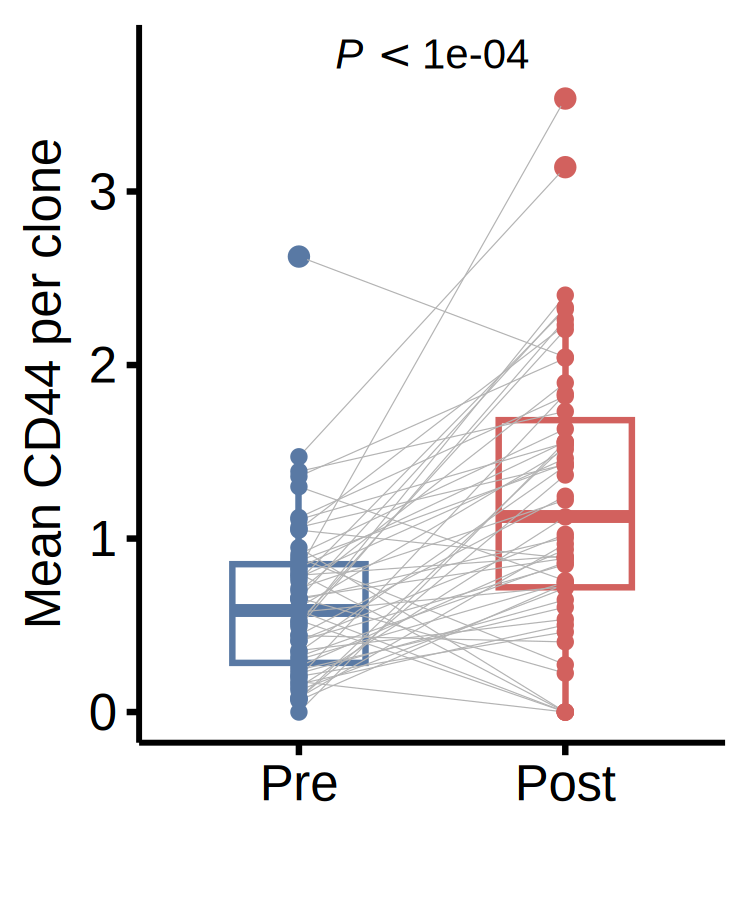

In [58]:
options(repr.plot.width = 2.5, repr.plot.height = 3, repr.plot.res = 300)

pal_tp = c('Pre' = '#5979A4', 'Post' = '#D2615E')

p_thresh = 1e-04
p_label = if (wilcox_res$p.value < p_thresh) {
    "italic(P) < 1e-04"
} else {
    paste0("italic(P) == ", signif(wilcox_res$p.value, 2))
}

p = ggpubr::ggpaired(
    cd44_clone %>% mutate(timepoint_label = factor(timepoint_label, levels = c('Pre', 'Post'))),
    x = 'timepoint_label', y = 'mean_CD44', id = 'clade',
    color = 'timepoint_label', line.color = 'grey70', line.size = 0.1,
    point.size = 1
) +
    scale_color_manual(values = pal_tp) +
    annotate('text', x = 1.5, y = Inf, vjust = 1.5, label = p_label, size = 3.5, parse = TRUE) +
    scale_y_continuous(expand = expansion(mult = c(0.05, 0.12))) +
    theme(legend.position = 'none') +
    xlab('') +
    ylab('Mean CD44 per clone') +
    theme_transparent

p

ggsave('outputs/MM_BB094_CD44_clone_paired_wilcox.pdf', p, width = 2.5, height = 3)

Warning message:
“The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


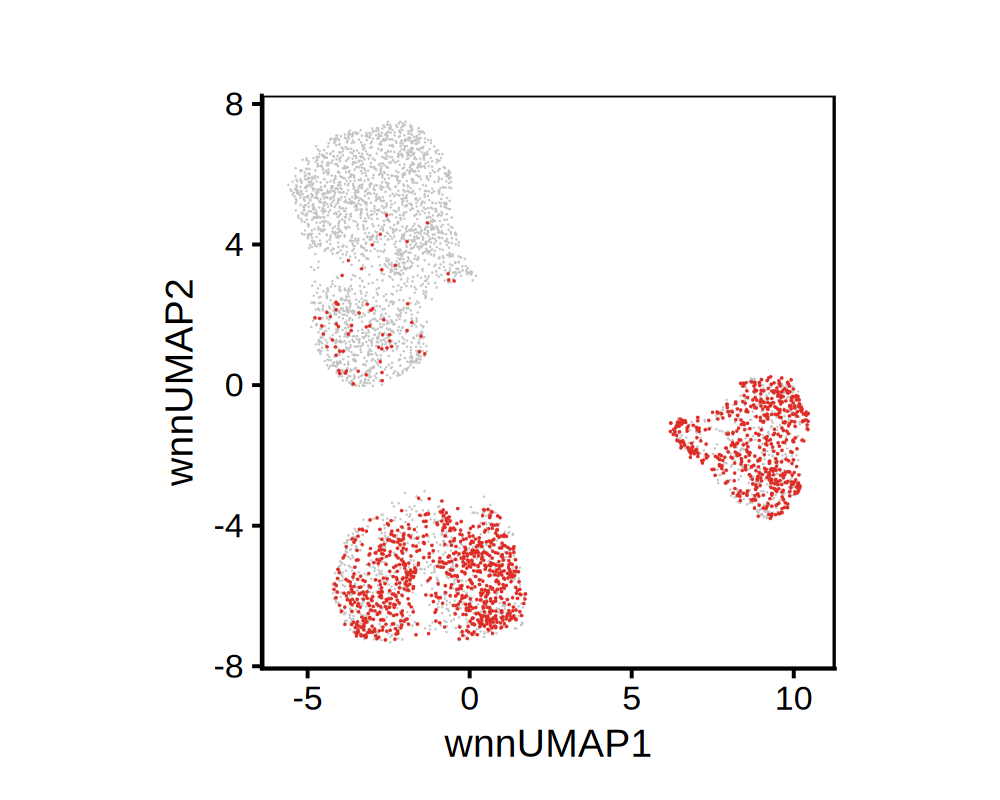

In [59]:
options(repr.plot.width = 5, repr.plot.height = 4, repr.plot.res = 200)

clone_cells = clade_annot %>%
    filter(clade %in% clones_include) %>%
    split(.$clade) %>%
    lapply(pull, cell)

p = DimPlot(
    seu_clean,
    cells.highlight = clone_cells,
    sizes.highlight = 0.5,
    pt.size = 0.3,
    stroke.size = 0,
    order = TRUE
) +
    ggtitle('') +
    theme(legend.position = 'none') +
    theme(aspect.ratio = 1) +
    xlab('wnnUMAP1') + ylab('wnnUMAP2') +
    theme(panel.border = element_rect(fill = NA, size = 0.5, color = 'black')) +
    theme_transparent

p %>% ggrastr::rasterize(layers = 'Point', dpi = 300)

# ggsave('outputs/MM_BB094_CD44_clones_umap.pdf', p %>% ggrastr::rasterize(layers = 'Point', dpi = 300), width = 5, height = 4)